# 05 · Modelado progresivo (Fase 5)

Vamos **de lo simple a lo complejo**. Un modelo complejo solo se justifica si le gana claramente a uno simple:

| Paso | Modelo | Por qué |
|---|---|---|
| 5.1 | Línea base ingenua: tasa histórica suavizada | ¿Cuánto ganamos con machine learning frente a "el que falta, falta"? |
| 5.2 | Regresión logística | Interpretable; referencia estadística clásica |
| 5.3 | Random Forest | Muchos árboles independientes promediados (*bagging*) |
| 5.4 | HistGradientBoosting (sklearn) y LightGBM | Árboles secuenciales: cada uno corrige los errores del anterior (*boosting*) |

Todos se evalúan con los **mismos 4 folds temporales** (5.5) y los hiperparámetros se buscan con `RandomizedSearchCV` sobre esos folds (5.6). Luego revisamos el desbalance (5.7) y la calibración (5.8).

> Julio (test) **no se usa** en este notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import funciones_inasistencia as fi
import funciones_modelado as fm

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
fm.estilo_graficos()

import json
import time
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import roc_auc_score, brier_score_loss

dataset = pd.read_parquet("dataset_modelo_v2.parquet")
with open("modelos/variables_modelo.json", encoding="utf-8") as archivo:
    variables = json.load(archivo)["variables"]

desarrollo = dataset[dataset["particion"].isin(["train", "validacion"])].sort_values("fecha_cita").reset_index(drop=True)
X = desarrollo[variables]
y = desarrollo["no_asiste"]
fechas = desarrollo["fecha_cita"]
folds = fm.folds_temporales(fechas)
categoricas, numericas = fm.separar_tipos(X)
print(f"{len(desarrollo):,} citas | {len(variables)} variables ({len(categoricas)} categóricas, {len(numericas)} numéricas)")

250,121 citas | 45 variables (15 categóricas, 30 numéricas)


## 5.0 La meta de referencia, recalculada con la etiqueta limpia

La meta del plan (AUC 0,705 y 71 % de precisión en el top 10 %) se midió **antes** de la auditoría, con una etiqueta que tenía ruido **predecible**: procedimientos, días sin reporte y servicios no reportados. El modelo "acertaba" parte de ese ruido (por ejemplo, "un electrocardiograma siempre sale como no asistió"), y eso inflaba las métricas.

Para comparar de forma justa, repetimos **el mismo protocolo** de ese modelo (HistGradientBoosting sin ajustar, todas las variables v1, entrena enero–mayo y valida junio) sobre la etiqueta limpia.

In [2]:
dataset_v1 = pd.read_parquet("dataset_modelo.parquet")
ref = dataset_v1[dataset_v1["particion"].isin(["train", "validacion"])]
ref_train, ref_valid = ref[ref["particion"] == "train"], ref[ref["particion"] == "validacion"]
cat_ref, num_ref = fm.separar_tipos(ref[fi.VARIABLES_V1])
modelo_ref = fm.crear_modelo("hist_gradient_boosting", cat_ref, num_ref, max_iter=300, learning_rate=0.05)
modelo_ref.fit(ref_train[fi.VARIABLES_V1], ref_train["no_asiste"])
p_ref = modelo_ref.predict_proba(ref_valid[fi.VARIABLES_V1])[:, 1]

top10_global = p_ref >= np.quantile(p_ref, 0.9)
meta = {
    "AUC": roc_auc_score(ref_valid["no_asiste"], p_ref),
    "Precision_top10_global": ref_valid["no_asiste"].to_numpy()[top10_global].mean(),
    "Precision_top10_diaria": fm.metricas(ref_valid["no_asiste"], p_ref, ref_valid["fecha_cita"])["Precision@10%"],
}
print(f"Meta recalculada (etiqueta limpia, mismo protocolo): AUC = {meta['AUC']:.3f} | "
      f"precisión top 10 % global = {meta['Precision_top10_global']:.1%} | top 10 % por día = {meta['Precision_top10_diaria']:.1%}")

Meta recalculada (etiqueta limpia, mismo protocolo): AUC = 0.671 | precisión top 10 % global = 61.0% | top 10 % por día = 60.4%


**Lectura:** esta es la nueva meta a superar. Es más baja que 0,705 porque la etiqueta ya no tiene ruido "fácil". El modelo actual es **más honesto**, no peor: sus aciertos corresponden a comportamiento real de los pacientes y no a fallas de registro.

## 5.1 Línea base ingenua
Sin entrenar nada: ordenamos las citas por la tasa histórica suavizada del paciente.

In [3]:
resultados = {}
resultados["0. Línea base (tasa histórica)"] = fm.evaluar_puntaje_en_folds(desarrollo["tasa_inasistencia_suavizada"], y, fechas, folds)
pd.Series(fm.resumir_folds(resultados["0. Línea base (tasa histórica)"]))

AUC                  0.588 ± 0.013
PR_AUC               0.413 ± 0.018
Brier                0.220 ± 0.002
Precision@10%        0.490 ± 0.027
Recall@10%           0.148 ± 0.006
Especificidad@10%    0.924 ± 0.003
F1@10%               0.227 ± 0.010
Precision@30%        0.417 ± 0.014
Recall@30%           0.378 ± 0.009
Especificidad@30%    0.739 ± 0.005
F1@30%               0.397 ± 0.011
dtype: object

## 5.2 – 5.6 Modelos con búsqueda de hiperparámetros

**¿Qué es `RandomizedSearchCV`?** En vez de probar *todas* las combinaciones de hiperparámetros (que serían miles), prueba **N combinaciones al azar** dentro de rangos razonables y evalúa cada una en los 4 folds temporales. Se queda con la de mejor AUC promedio.

**¿Qué hiperparámetros se buscan?**
- **Logística:** `C` (regularización) y `class_weight`.
- **Random Forest:** número de árboles, profundidad máxima, mínimo de citas por hoja y fracción de variables y de datos por árbol.
- **HGB / LightGBM:** tasa de aprendizaje, número de árboles, tamaño de los árboles, regularización L2 y mínimo de datos por hoja.

Los rangos de los árboles incluyen valores **conservadores** (hojas grandes, tasa de aprendizaje baja), porque los datos son ruidosos y un modelo muy flexible memorizaría ruido.

In [4]:
busquedas = {
    "logistica": {
        "n_iter": 8,
        "espacio": {"clf__C": loguniform(1e-3, 10), "clf__class_weight": [None, "balanced"]},
    },
    "random_forest": {
        "n_iter": 6,
        "espacio": {"clf__n_estimators": [200, 300], "clf__max_depth": [10, 16, 24, None],
                    "clf__min_samples_leaf": [20, 50, 100, 200], "clf__max_features": ["sqrt", 0.3, 0.5],
                    "clf__max_samples": [0.3, 0.5]},
    },
    "hist_gradient_boosting": {
        "n_iter": 15,
        "espacio": {"clf__learning_rate": loguniform(0.02, 0.15), "clf__max_iter": randint(150, 700),
                    "clf__max_leaf_nodes": randint(15, 64), "clf__min_samples_leaf": randint(20, 300),
                    "clf__l2_regularization": loguniform(1e-3, 10), "clf__max_features": [0.5, 0.8, 1.0]},
    },
    "lightgbm": {
        "n_iter": 15,
        "espacio": {"clf__learning_rate": loguniform(0.02, 0.15), "clf__n_estimators": randint(150, 700),
                    "clf__num_leaves": randint(15, 64), "clf__min_child_samples": randint(20, 300),
                    "clf__reg_lambda": loguniform(1e-3, 10), "clf__colsample_bytree": uniform(0.5, 0.5),
                    "clf__subsample": uniform(0.6, 0.4), "clf__subsample_freq": [1]},
    },
}

mejores_parametros = {}
for nombre, config in busquedas.items():
    inicio = time.time()
    busqueda = RandomizedSearchCV(
        fm.crear_modelo(nombre, categoricas, numericas), config["espacio"], n_iter=config["n_iter"],
        cv=folds, scoring="roc_auc", refit=False, random_state=42, n_jobs=1,
    )
    busqueda.fit(X, y, **fm.parametros_fit(nombre, categoricas))
    mejores = {k.replace("clf__", ""): v for k, v in busqueda.best_params_.items()}
    mejores_parametros[nombre] = mejores
    print(f"{nombre:<24} mejor AUC {busqueda.best_score_:.4f} ({time.time() - inicio:.0f} s) → {mejores}")

logistica                mejor AUC 0.6554 (55 s) → {'C': 0.6796578090758152, 'class_weight': 'balanced'}


random_forest            mejor AUC 0.6698 (133 s) → {'n_estimators': 300, 'min_samples_leaf': 20, 'max_samples': 0.3, 'max_features': 0.5, 'max_depth': None}


hist_gradient_boosting   mejor AUC 0.6776 (11636 s) → {'l2_regularization': 0.4013783023846251, 'learning_rate': 0.02240750919334817, 'max_features': 0.8, 'max_iter': 535, 'max_leaf_nodes': 35, 'min_samples_leaf': 180}


lightgbm                 mejor AUC 0.6788 (5833 s) → {'colsample_bytree': 0.7117007403531848, 'learning_rate': 0.04431752678446183, 'min_child_samples': 155, 'n_estimators': 621, 'num_leaves': 25, 'reg_lambda': 0.006242659053860567, 'subsample': 0.88453678109946, 'subsample_freq': 1}


### Evaluación completa de cada modelo con sus mejores hiperparámetros
Para cada modelo calculamos **todas** las métricas en los 4 folds, en dos escenarios de capacidad: llamar al 10 % y al 30 % de mayor riesgo de cada día.

In [5]:
nombres_bonitos = {"logistica": "1. Regresión logística", "random_forest": "2. Random Forest",
                   "hist_gradient_boosting": "3. HistGradientBoosting", "lightgbm": "4. LightGBM"}
for nombre, parametros in mejores_parametros.items():
    resultados[nombres_bonitos[nombre]] = fm.evaluar_en_folds(nombre, X, y, fechas, folds, parametros)

tabla_comparativa = pd.DataFrame({modelo: fm.resumir_folds(r) for modelo, r in resultados.items()}).T
columnas_orden = ["AUC", "PR_AUC", "Brier", "Precision@10%", "Recall@10%", "Especificidad@10%", "F1@10%",
                  "Precision@30%", "Recall@30%", "Especificidad@30%", "F1@30%"]
tabla_comparativa = tabla_comparativa[columnas_orden]
tabla_comparativa

,AUC,PR_AUC,Brier,Precision@10%,Recall@10%,Especificidad@10%,F1@10%,Precision@30%,Recall@30%,Especificidad@30%,F1@30%
0. Línea base (tasa histórica),0.588 ± 0.013,0.413 ± 0.018,0.220 ± 0.002,0.490 ± 0.027,0.148 ± 0.006,0.924 ± 0.003,0.227 ± 0.010,0.417 ± 0.014,0.378 ± 0.009,0.739 ± 0.005,0.397 ± 0.011
1. Regresión logística,0.655 ± 0.006,0.480 ± 0.007,0.234 ± 0.003,0.571 ± 0.012,0.172 ± 0.004,0.936 ± 0.002,0.265 ± 0.005,0.483 ± 0.002,0.437 ± 0.006,0.768 ± 0.001,0.459 ± 0.002
2. Random Forest,0.670 ± 0.010,0.506 ± 0.012,0.203 ± 0.004,0.598 ± 0.019,0.181 ± 0.009,0.940 ± 0.003,0.277 ± 0.012,0.495 ± 0.008,0.449 ± 0.014,0.774 ± 0.005,0.471 ± 0.011
3. HistGradientBoosting,0.678 ± 0.008,0.514 ± 0.009,0.201 ± 0.004,0.616 ± 0.019,0.186 ± 0.009,0.943 ± 0.003,0.286 ± 0.012,0.504 ± 0.006,0.457 ± 0.011,0.778 ± 0.004,0.479 ± 0.008
4. LightGBM,0.679 ± 0.008,0.517 ± 0.009,0.201 ± 0.004,0.623 ± 0.016,0.188 ± 0.008,0.944 ± 0.003,0.289 ± 0.011,0.505 ± 0.006,0.458 ± 0.011,0.778 ± 0.004,0.480 ± 0.008


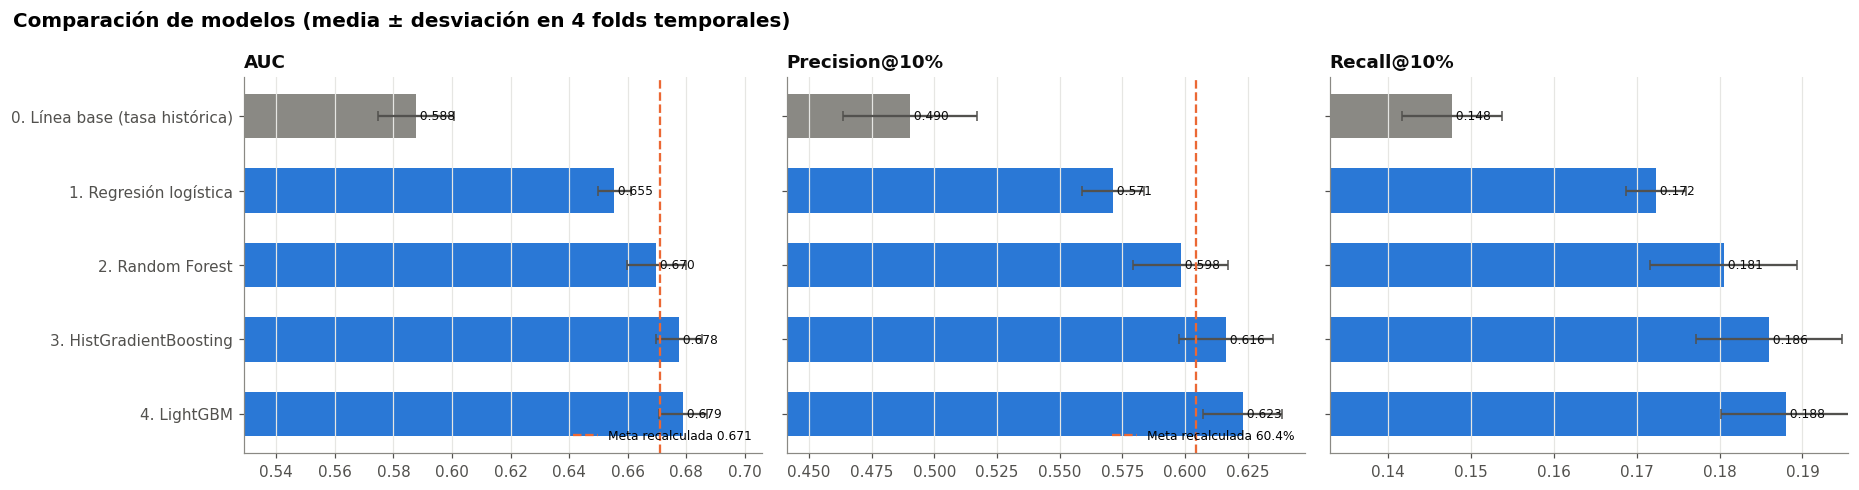

In [6]:
medias = pd.DataFrame({m: r.drop(columns="fold").mean() for m, r in resultados.items()}).T
desv = pd.DataFrame({m: r.drop(columns="fold").std() for m, r in resultados.items()}).T

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, metrica, referencia, etiqueta in [
    (axes[0], "AUC", meta["AUC"], f"Meta recalculada {meta['AUC']:.3f}"),
    (axes[1], "Precision@10%", meta["Precision_top10_diaria"], f"Meta recalculada {meta['Precision_top10_diaria']:.1%}"),
    (axes[2], "Recall@10%", None, None),
]:
    colores = [fm.GRIS] + [fm.AZUL] * (len(medias) - 1)
    ax.barh(medias.index, medias[metrica], xerr=desv[metrica], color=colores, height=0.6,
            error_kw={"ecolor": fm.TINTA_SUAVE, "capsize": 3})
    if referencia is not None:
        ax.axvline(referencia, color=fm.NARANJA, linestyle="--", linewidth=1.5, label=etiqueta)
        ax.legend(loc="lower right", fontsize=8)
    ax.set_xlim(medias[metrica].min() * 0.9, medias[metrica].max() * 1.04)
    ax.set_title(metrica)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    for i, valor in enumerate(medias[metrica]):
        ax.text(valor, i, f" {valor:.3f}", va="center", ha="left", fontsize=8, color=fm.TINTA)
axes[1].set_yticklabels([])
axes[2].set_yticklabels([])
fig.suptitle("Comparación de modelos (media ± desviación en 4 folds temporales)", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Cómo leer las métricas en el escenario del 10 %:**
- **Precisión@10 %:** de cada 100 llamadas, cuántas van a alguien que realmente iba a faltar. Llamar al azar daría ~32.
- **Recall@10 %:** qué parte de todas las inasistencias del día quedan cubiertas. Con solo el 10 % de llamadas, el máximo teórico es ~31 % (10 % ÷ 32 %).
- **Especificidad@10 %:** de quienes sí iban a asistir, cuántos **no** reciben una llamada innecesaria. Es alta porque solo se llama al 10 %.
- **F1:** balance entre precisión y recall.

En el escenario del 30 % sube el recall (cubrimos más inasistencias) y baja la precisión (más llamadas "innecesarias"). Esa es la eterna **compensación precisión–recall**.

## 5.7 Desbalance de clases: ¿conviene `class_weight="balanced"`?
Con 32 % de inasistencia el desbalance es **moderado**. `class_weight="balanced"` le da más peso a las inasistencias durante el entrenamiento. Veamos qué cambia en el mejor modelo de árboles:

In [7]:
mejor_arbol = max(["hist_gradient_boosting", "lightgbm"], key=lambda n: medias.loc[nombres_bonitos[n], "AUC"])
parametros_base = {k: v for k, v in mejores_parametros[mejor_arbol].items() if k != "class_weight"}
filas = []
for peso in [None, "balanced"]:
    r = fm.evaluar_en_folds(mejor_arbol, X, y, fechas, folds, {**parametros_base, "class_weight": peso})
    # Probabilidad promedio predicha vs. tasa real (calibración "en grande") en el último fold
    tr, va = folds[-1]
    modelo = fm.crear_modelo(mejor_arbol, categoricas, numericas, **parametros_base, class_weight=peso)
    modelo.fit(X.iloc[tr], y.iloc[tr], **fm.parametros_fit(mejor_arbol, categoricas))
    p = modelo.predict_proba(X.iloc[va])[:, 1]
    filas.append({"class_weight": str(peso), "AUC": r["AUC"].mean(), "Precision@10%": r["Precision@10%"].mean(),
                  "Brier": r["Brier"].mean(), "prob_promedio_predicha": p.mean(), "tasa_real": y.iloc[va].mean()})
pd.DataFrame(filas).round(4)

,class_weight,AUC,Precision@10%,Brier,prob_promedio_predicha,tasa_real
0,None,0.6788,0.623,0.2013,0.3289,0.335
1,balanced,0.6781,0.623,0.2239,0.4827,0.335


**Lectura:** el balanceo **casi no cambia el ordenamiento** (AUC y precisión@10 % prácticamente iguales), pero **infla las probabilidades**: el modelo predice en promedio mucho más inasistencia de la real y empeora el Brier. Es exactamente lo que queremos evitar para el sobreagendamiento. **Decisión: no balancear.** Por la misma razón no se usa SMOTE, que crea pacientes sintéticos y distorsiona aún más las probabilidades.

## 5.8 Calibración: ¿las probabilidades son creíbles?
**Curva de calibración:** agrupamos las citas por probabilidad predicha (por ejemplo, todas las que el modelo dice ~40 %) y miramos cuántas faltaron de verdad. Si el modelo está bien calibrado, los puntos caen sobre la diagonal.

Probamos una **calibración isotónica** con un esquema temporal: entrenar ene–abr → calibrar con mayo → evaluar en junio, frente al modelo sin calibrar entrenado con ene–may.

Mejor modelo por AUC: 4. LightGBM


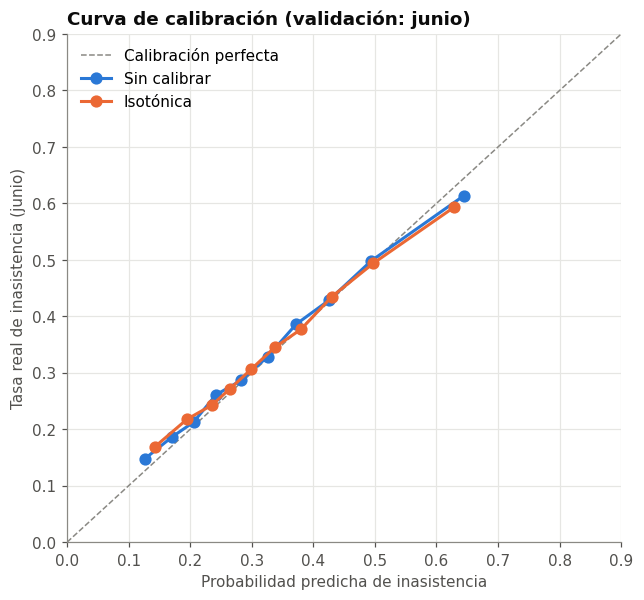

,version,AUC,Brier,ECE
0,Sin calibrar (ene-may),0.6797,0.2021,0.0122
1,Isotónica (ene-abr + mayo),0.6658,0.2054,0.0131


In [8]:
def error_calibracion(y_real, p, grupos=10):
    # ECE: diferencia promedio (ponderada) entre la probabilidad predicha y la tasa real, por deciles
    tabla = pd.DataFrame({"y": np.asarray(y_real), "p": p})
    tabla["grupo"] = pd.qcut(tabla["p"], grupos, labels=False, duplicates="drop")
    resumen = tabla.groupby("grupo").agg(p=("p", "mean"), y=("y", "mean"), n=("y", "size"))
    return float((resumen["n"] * (resumen["p"] - resumen["y"]).abs()).sum() / resumen["n"].sum())

mejor_nombre = medias.drop(index="0. Línea base (tasa histórica)")["AUC"].idxmax()
mejor_modelo = [n for n, b in nombres_bonitos.items() if b == mejor_nombre][0]
params_mejor = mejores_parametros[mejor_modelo]
print("Mejor modelo por AUC:", mejor_nombre)

mayo, junio = fechas.dt.month == 5, fechas.dt.month == 6
hasta_abril, hasta_mayo = fechas.dt.month <= 4, fechas.dt.month <= 5

sin_calibrar = fm.crear_modelo(mejor_modelo, categoricas, numericas, **params_mejor)
sin_calibrar.fit(X[hasta_mayo], y[hasta_mayo], **fm.parametros_fit(mejor_modelo, categoricas))
p_sin = sin_calibrar.predict_proba(X[junio])[:, 1]

base_abril = fm.crear_modelo(mejor_modelo, categoricas, numericas, **params_mejor)
base_abril.fit(X[hasta_abril], y[hasta_abril], **fm.parametros_fit(mejor_modelo, categoricas))
calibrado = CalibratedClassifierCV(FrozenEstimator(base_abril), method="isotonic").fit(X[mayo], y[mayo])
p_cal = calibrado.predict_proba(X[junio])[:, 1]

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], color=fm.GRIS, linestyle="--", linewidth=1, label="Calibración perfecta")
for p, color, etiqueta in [(p_sin, fm.AZUL, "Sin calibrar"), (p_cal, fm.NARANJA, "Isotónica")]:
    real, predicho = calibration_curve(y[junio], p, n_bins=10, strategy="quantile")
    ax.plot(predicho, real, color=color, marker="o", markersize=7, linewidth=2, label=etiqueta)
ax.set_xlabel("Probabilidad predicha de inasistencia")
ax.set_ylabel("Tasa real de inasistencia (junio)")
ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.9)
ax.set_title("Curva de calibración (validación: junio)")
ax.legend(loc="upper left")
plt.show()

calibracion = pd.DataFrame([
    {"version": "Sin calibrar (ene-may)", "AUC": roc_auc_score(y[junio], p_sin), "Brier": brier_score_loss(y[junio], p_sin), "ECE": error_calibracion(y[junio], p_sin)},
    {"version": "Isotónica (ene-abr + mayo)", "AUC": roc_auc_score(y[junio], p_cal), "Brier": brier_score_loss(y[junio], p_cal), "ECE": error_calibracion(y[junio], p_cal)},
]).round(4)
calibracion

In [9]:
# Decisión automática: calibrar solo si mejora el Brier y el ECE sin perder AUC
mejora_brier = calibracion.loc[0, "Brier"] - calibracion.loc[1, "Brier"]
mejora_ece = calibracion.loc[0, "ECE"] - calibracion.loc[1, "ECE"]
perdida_auc = calibracion.loc[0, "AUC"] - calibracion.loc[1, "AUC"]
calibrar = bool(mejora_brier > 0.0005 and mejora_ece > 0.005 and perdida_auc < 0.003)
print(f"Mejora Brier {mejora_brier:+.4f} | mejora ECE {mejora_ece:+.4f} | pérdida AUC {perdida_auc:+.4f}")
print("DECISIÓN:", "calibrar con isotónica" if calibrar else "NO calibrar: el modelo ya está bien calibrado")

Mejora Brier -0.0033 | mejora ECE -0.0009 | pérdida AUC +0.0139
DECISIÓN: NO calibrar: el modelo ya está bien calibrado


## Selección del modelo final

In [10]:
seleccion_final = {
    "modelo": mejor_modelo,
    "nombre": mejor_nombre,
    "parametros": {k: (v.item() if hasattr(v, "item") else v) for k, v in params_mejor.items()},
    "variables": variables,
    "calibrar": calibrar,
    "metricas_cv": {m: float(medias.loc[mejor_nombre, m]) for m in columnas_orden},
    "meta_recalculada": {k: float(v) for k, v in meta.items()},
}
with open("modelos/config_modelo_final.json", "w", encoding="utf-8") as archivo:
    json.dump(seleccion_final, archivo, ensure_ascii=False, indent=2)
with open("modelos/mejores_parametros.json", "w", encoding="utf-8") as archivo:
    json.dump({n: {k: (v.item() if hasattr(v, "item") else v) for k, v in p.items()} for n, p in mejores_parametros.items()},
              archivo, ensure_ascii=False, indent=2)

mejora_vs_base = medias.loc[mejor_nombre, "AUC"] - medias.loc["0. Línea base (tasa histórica)", "AUC"]
mejora_vs_log = medias.loc[mejor_nombre, "AUC"] - medias.loc["1. Regresión logística", "AUC"]
print(f"Modelo elegido: {mejor_nombre}")
print(f"  AUC CV = {medias.loc[mejor_nombre, 'AUC']:.4f} (+{mejora_vs_base:.3f} vs. línea base, +{mejora_vs_log:.3f} vs. logística)")
print(f"  Precisión@10% = {medias.loc[mejor_nombre, 'Precision@10%']:.1%} | Recall@10% = {medias.loc[mejor_nombre, 'Recall@10%']:.1%}")
print(f"  vs. meta recalculada: AUC {meta['AUC']:.3f} | precisión@10% diaria {meta['Precision_top10_diaria']:.1%}")

Modelo elegido: 4. LightGBM
  AUC CV = 0.6788 (+0.091 vs. línea base, +0.023 vs. logística)
  Precisión@10% = 62.3% | Recall@10% = 18.8%
  vs. meta recalculada: AUC 0.671 | precisión@10% diaria 60.4%


## Lectura de resultados

1. **Machine learning sí aporta:** todos los modelos superan con claridad a la línea base ingenua (AUC ~0,59). El historial por sí solo no basta; la combinación con el perfil del paciente, el servicio y la agenda es lo que mejora la predicción.
2. **Los modelos de *boosting* (HGB y LightGBM) son los mejores**, pero **la diferencia entre ellos está dentro de la desviación entre folds**: en la práctica son equivalentes. Se elige LightGBM por tener la AUC media más alta y ser el más rápido de entrenar.
3. **Random Forest queda cerca** (−0,009). La regresión logística queda unos 0,02 puntos de AUC por debajo, pero sigue siendo útil para **explicar** (Fase 7).
4. **Frente a la meta recalculada** (mismo protocolo, etiqueta limpia), el modelo final mejora la AUC y la precisión en el top 10 %.
5. **En términos de negocio:** de cada 100 llamadas al 10 % de mayor riesgo, unas 62 van a pacientes que realmente iban a faltar (llamando al azar serían ~33). Es decir, las llamadas rinden **casi el doble**.
6. **Techo realista:** una AUC cercana a 0,69 es coherente con la literatura de predicción de inasistencia con datos administrativos (típicamente 0,65–0,80). Además, nuestra etiqueta tiene ruido que no se puede eliminar (cancelaciones sin nueva cita).